In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive, files

from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model

from keras.layers import Conv1D, Dense, Dropout, Input, Concatenate, GlobalMaxPooling1D
from keras.models import Model

tf.test.gpu_device_name()
print(tf.__version__)

2.6.0


In [70]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### Data importation

In [71]:
vis = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/vis_54_winter_mod.npy')
temp = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/t_54_winter_mod.npy')
dew = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/dt_54_winter_mod.npy')
ws = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/ws_54_winter_mod.npy')
wd = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/wd_54_winter_mod.npy')

ttd = temp - dew

In [72]:
interest_list = [4,10,20,21,41,48,50,51]

In [73]:
STN = 48

In [74]:
obs_data = np.stack((vis[:,STN],temp[:,STN],ttd[:,STN],ws[:,STN],wd[:,STN]), axis = -1)
obs_data.shape

(131328, 5)

In [75]:
interest_list = [num for num in interest_list if num != STN]
print(interest_list)

[4, 10, 20, 21, 41, 50, 51]


In [76]:
stations_list = []

for num in interest_list :

  test = np.stack((vis[:,num],temp[:,num],ttd[:,num],ws[:,num],wd[:,num]), axis = -1)
  stations_list.append(test)

#model_data = np.stack(tuple(stations_list), axis = -1)
model_data = stations_list[1]

In [77]:
print(model_data.shape)

(131328, 5)


In [78]:
for i in range(10) :

  print(model_data[i])

[ 8.5350e+03 -2.9000e+00  2.4000e+00  1.3608e+00  6.3000e+01]
[ 8.247e+03 -2.800e+00  2.400e+00  1.944e-01  9.100e+01]
[ 7.659e+03 -2.800e+00  2.500e+00  9.720e-01  1.080e+02]
[ 7.841e+03 -2.900e+00  2.500e+00  5.832e-01  6.500e+01]
[ 7.649e+03 -2.900e+00  2.500e+00  5.832e-01  4.600e+01]
[ 7.567e+03 -2.800e+00  2.500e+00  5.832e-01  7.200e+01]
[ 7.701e+03 -2.800e+00  2.500e+00  5.832e-01  7.400e+01]
[ 7.515e+03 -2.800e+00  2.500e+00  7.776e-01  1.050e+02]
[ 7.8390e+03 -2.8000e+00  2.5000e+00  1.1664e+00  6.1000e+01]
[ 7.7180e+03 -2.8000e+00  2.5000e+00  1.3608e+00  5.1000e+01]


In [79]:
print(obs_data.shape)
print(model_data.shape)

(131328, 5)
(131328, 5)


In [80]:
bins = [-1, 150, 350, 600, 800, 1500, 3000, 5000, 30000]
obs_data[:,0] = pd.cut(obs_data[:,0], bins, labels=[0,1,2,3,4,5,6,7]).to_numpy()

In [81]:
for i in range(10) :

  print(obs_data[i])
  print(model_data[i])
  print()

[ 5.    -3.4    1.7    2.916 37.   ]
[ 8.5350e+03 -2.9000e+00  2.4000e+00  1.3608e+00  6.3000e+01]

[ 6.     -3.4     1.7     3.1104 33.    ]
[ 8.247e+03 -2.800e+00  2.400e+00  1.944e-01  9.100e+01]

[ 6.     -3.4     1.7     1.7496 35.    ]
[ 7.659e+03 -2.800e+00  2.500e+00  9.720e-01  1.080e+02]

[ 6.    -3.4    1.8    0.972 60.   ]
[ 7.841e+03 -2.900e+00  2.500e+00  5.832e-01  6.500e+01]

[ 6.     -3.3     1.9     0.7776 39.    ]
[ 7.649e+03 -2.900e+00  2.500e+00  5.832e-01  4.600e+01]

[  6.      -3.3      2.       1.5552 348.    ]
[ 7.567e+03 -2.800e+00  2.500e+00  5.832e-01  7.200e+01]

[  6.     -3.4     1.9     1.944 338.   ]
[ 7.701e+03 -2.800e+00  2.500e+00  5.832e-01  7.400e+01]

[ 7.    -3.3    2.2    0.972 17.   ]
[ 7.515e+03 -2.800e+00  2.500e+00  7.776e-01  1.050e+02]

[ 7.     -3.2     2.      1.3608 36.    ]
[ 7.8390e+03 -2.8000e+00  2.5000e+00  1.1664e+00  6.1000e+01]

[ 7.     -3.2     2.1     1.7496 33.    ]
[ 7.7180e+03 -2.8000e+00  2.5000e+00  1.3608e+00  5.1000e+

In [82]:
# Split into training data
TRAIN_SPLIT = np.int(0.8*len(obs_data))
print(TRAIN_SPLIT)

105062


In [83]:
# Use the past_history nr of data to predict future_target nr of data
past_history = 12
future_target = 6

### Data preparation

In [84]:
def multivariate_data_obs(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

def multivariate_data_model(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i+target_size, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [85]:
STEP = 1

# Split into training and testing data
x_obs_train, y_obs_train = multivariate_data_obs(obs_data, obs_data, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_obs_test, y_obs_test = multivariate_data_obs(obs_data, obs_data,
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

x_model_train, _ = multivariate_data_model(model_data, model_data, 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_model_test, _ = multivariate_data_model(model_data, model_data,
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

In [86]:
# Normalize the data (all features except for visibility)
x_obs_min = x_obs_train.min(axis=(0,1))
x_obs_max = x_obs_train.max(axis=(0,1))
x_model_min = x_model_train.min(axis=(0,1))
x_model_max = x_model_train.max(axis=(0,1))

x_obs_train[:,:,1:] = (x_obs_train[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])
x_obs_test[:,:,1:] = (x_obs_test[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])

y_obs_train[:,:,1:] = (y_obs_train[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])
y_obs_test[:,:,1:] = (y_obs_test[:,:,1:]-x_obs_min[1:])/(x_obs_max[1:]-x_obs_min[1:])

x_model_train = (x_model_train-x_model_min)/(x_model_max-x_model_min)
x_model_test = (x_model_test-x_model_min)/(x_model_max-x_model_min)

In [87]:
# Implements over- and undersampling of the data
def resample_data(x_obs, y_obs, x_model, no_classes, samples_per_class):
  
  class_counts = np.zeros(no_classes).astype(np.int32)
  class_indices = []

  a = np.arange(0,len(y_obs),1)

  x_res = np.zeros((sum(samples_per_class), x_obs.shape[1], x_obs.shape[2]))
  y_res = np.zeros((sum(samples_per_class), y_obs.shape[1], y_obs.shape[2]))
  x_res_model = np.zeros((sum(samples_per_class), x_model.shape[1], x_model.shape[2]))

  k = 0
  for i in range(no_classes):

    # Indices of class i in dataset
    curr_class_index = a[np.any(y_obs[:,:,0]==i, axis=1)]

    # Resample class i to have precisely samples_per_class occurrences
    resampled_class_index = resample(curr_class_index, replace=True, 
                                     n_samples=samples_per_class[i])
    samples = len(resampled_class_index)

    x_res[k:k+samples,] = x_obs[resampled_class_index,]
    y_res[k:k+samples,] = y_obs[resampled_class_index,]
    x_res_model[k:k+samples,] = x_model[resampled_class_index,]
    k += samples

  return x_res, y_res, x_model

In [88]:
#class_samples = [5000,100,1000,10000,1500,1000,8000,10000]
#x_obs_res, y_obs_res, x_model_res = resample_data(x_obs_train, y_obs_train, x_model_train, 8, class_samples)

In [89]:
x_obs_res, y_obs_res, x_model_res = x_obs_train, y_obs_train, x_model_train

(array([[  188.,  1108.,   932.,   502.,  2201.,  7357., 11492., 81270.],
        [  188.,  1108.,   932.,   502.,  2201.,  7357., 11491., 81271.],
        [  188.,  1108.,   932.,   502.,  2201.,  7357., 11490., 81272.],
        [  188.,  1108.,   932.,   502.,  2201.,  7356., 11490., 81273.],
        [  188.,  1108.,   932.,   502.,  2201.,  7355., 11490., 81274.],
        [  188.,  1108.,   932.,   502.,  2201.,  7354., 11490., 81275.]]),
 array([0.   , 0.875, 1.75 , 2.625, 3.5  , 4.375, 5.25 , 6.125, 7.   ]),
 <a list of 6 Lists of Patches objects>)

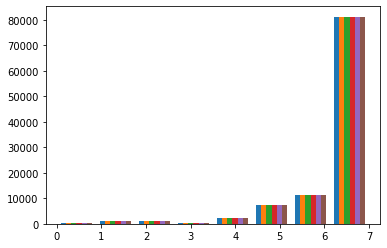

In [90]:
plt.hist(y_obs_res[:,:,0], bins=8)

In [91]:
# Total number of model features
nr_features_obs = x_obs_res.shape[2]
nr_features_model = x_model_res.shape[2]

In [92]:
print(nr_features_obs)
print(nr_features_model)

5
5


In [93]:
# Data shape
print ('Single window of past history : {}'.format(x_model_res[0].shape))
print ('Target window to predict : {}'.format(y_obs_res[0].shape))

Single window of past history : (18, 5)
Target window to predict : (6, 5)


In [94]:
from sklearn.utils import compute_class_weight

classes = np.array([i for i in range(8)])
weights = compute_class_weight(None, classes, obs_data.T[0])

class_weights = dict(zip(classes, weights))

In [95]:
print(class_weights)

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0}


In [96]:
def multi_layer_cross_entropy(y_true, y_pred):

  t = np.ones(future_target)
  
  loss = t[0]*tf.keras.losses.sparse_categorical_crossentropy(y_true[:,0], y_pred[:,0,:]) + \
  0*tf.cast(tf.keras.losses.mse(y_true[:,0], tf.math.argmax(y_pred[:,0,:], axis=1)), tf.float32)

  for i in range(1, future_target):
    y_true_step_i = y_true[:,i]
    y_pred_step_i = y_pred[:,i,:]
    loss += t[i]*tf.keras.losses.sparse_categorical_crossentropy(y_true_step_i, y_pred_step_i) + \
    0*tf.cast(tf.keras.losses.mse(y_true_step_i, tf.math.argmax(y_pred_step_i, axis=1)), tf.float32)
  return loss

In [97]:
print(x_obs_train.shape)
print(y_obs_train.shape)

print(x_obs_test.shape)
print(y_obs_test.shape)

print(x_model_train.shape)
print(x_model_test.shape)


(105050, 12, 5)
(105050, 6, 5)
(26248, 12, 5)
(26248, 6, 5)
(105050, 18, 5)
(26248, 18, 5)


In [98]:
def slice(x, length):
  return x[:,-length:,:]

In [99]:
input_shape_obs = (past_history, nr_features_obs,)
input_shape_model = (past_history+future_target, nr_features_model)

in_obs = tf.keras.layers.Input(shape=input_shape_obs)
in_model = tf.keras.layers.Input(shape=input_shape_model)

b_obs = tf.keras.layers.LSTM(32, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(in_obs)
b_obs = tf.keras.layers.Lambda(slice, arguments={'length': 1})(b_obs)
b_obs = tf.keras.layers.Flatten()(b_obs)
b_obs = tf.keras.layers.RepeatVector(future_target)(b_obs)

b_model = tf.keras.layers.LSTM(32, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(in_model)
b_model = tf.keras.layers.Lambda(slice, arguments={'length': future_target})(b_model)

b = tf.keras.layers.Concatenate(axis=2)([b_obs, b_model])
# b = b_obs
b = tf.keras.layers.LSTM(16, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(b)
b = tf.keras.layers.LSTM(8, return_sequences=True,
                             recurrent_regularizer=tf.keras.regularizers.l2())(b)
out = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(8, activation='softmax'))(b)

model = tf.keras.models.Model([in_obs, in_model], out)
model.compile(optimizer='adam', loss=multi_layer_cross_entropy, metrics=['acc'])
model.summary()

Model: "model_6"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_11 (InputLayer)           [(None, 12, 5)]      0                                            
__________________________________________________________________________________________________
lstm_8 (LSTM)                   (None, 12, 32)       4864        input_11[0][0]                   
__________________________________________________________________________________________________
lambda_4 (Lambda)               (None, 1, 32)        0           lstm_8[0][0]                     
__________________________________________________________________________________________________
input_12 (InputLayer)           [(None, 18, 5)]      0                                            
____________________________________________________________________________________________

In [100]:
multi_step_history = model.fit([x_obs_res, x_model_res], y_obs_res[:,:,0], 
                               batch_size=256, epochs=20, class_weight=class_weights)

Epoch 1/20
411/411 [==============================] - 24s 38ms/step - loss: 4.8512 - acc: 0.8153
Epoch 2/20
411/411 [==============================] - 16s 39ms/step - loss: 2.3587 - acc: 0.8844
Epoch 3/20
411/411 [==============================] - 16s 39ms/step - loss: 2.1002 - acc: 0.8974
Epoch 4/20
411/411 [==============================] - 16s 39ms/step - loss: 2.0093 - acc: 0.8994
Epoch 5/20
411/411 [==============================] - 16s 39ms/step - loss: 1.9531 - acc: 0.9008
Epoch 6/20
411/411 [==============================] - 16s 38ms/step - loss: 1.9150 - acc: 0.9017
Epoch 7/20
411/411 [==============================] - 16s 38ms/step - loss: 1.8859 - acc: 0.9024
Epoch 8/20
411/411 [==============================] - 16s 39ms/step - loss: 1.8655 - acc: 0.9028
Epoch 9/20
411/411 [==============================] - 16s 40ms/step - loss: 1.8458 - acc: 0.9031
Epoch 10/20
411/411 [==============================] - 16s 39ms/step - loss: 1.8265 - acc: 0.9035
Epoch 11/20
411/411 [========

In [101]:
# #this base model is one branch of the main model
# #it takes a time series as an input, performs 1-D convolution, and returns it as an output ready for concatenation

# def get_base_model(input_len, fsize):
#   #the input is a time series of length n and width 19
#   input_seq = Input(shape=(input_len, 4))
#   #choose the number of convolution filters
#   nb_filters = 10
#   #1-D convolution and global max-pooling
#   convolved = Conv1D(nb_filters, fsize, padding="same", activation="tanh")(input_seq)
#   processed = GlobalMaxPooling1D()(convolved)
#   #dense layer with dropout regularization
#   compressed = Dense(50, activation="tanh")(processed)
#   compressed = Dropout(0.3)(compressed)
#   model = Model(inputs=input_seq, outputs=compressed)
#   return model

# #this is the main model
# #it takes the original time series and its down-sampled versions as an input, and returns the result of classification as an output

# def main_model(inputs_lens = [5000, 30000, 131328], fsizes = [8,16,24]):
#   #the inputs to the branches are the original time series, and its down-sampled versions
#   input_smallseq = Input(shape=(inputs_lens[0], 4))
#   input_medseq = Input(shape=(inputs_lens[1] , 4))
#   input_origseq = Input(shape=(inputs_lens[2], 4))#the more down-sampled the time series, the shorter the corresponding filter
#   base_net_small = get_base_model(inputs_lens[0], fsizes[0])
#   base_net_med = get_base_model(inputs_lens[1], fsizes[1])
#   base_net_original = get_base_model(inputs_lens[2], fsizes[2])
#   embedding_small = base_net_small(input_smallseq)
#   embedding_med = base_net_med(input_medseq)
#   embedding_original = base_net_original(input_origseq)#concatenate all the outputs
#   merged = Concatenate()([embedding_small, embedding_med, embedding_original])
#   out = Dense(1, activation='sigmoid')(merged)
#   model = Model(inputs=[input_smallseq, input_medseq, input_origseq], outputs=out)
#   return model

# model = main_model()
# model.compile(optimizer='adam', loss=multi_layer_cross_entropy, metrics=['acc'])
# model.summary()

In [102]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs = range(len(loss))

  plt.figure()

  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()

  plt.show()

In [103]:
#plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

Text(0, 0.5, 'class')

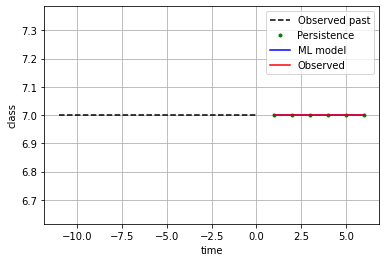

In [104]:
# Plot some results
ix = np.random.randint(0, len(x_obs_test))

vis = np.expand_dims(x_obs_test[ix,:,0], axis=0)
true_vis = np.expand_dims(y_obs_test[ix,:,0], axis=0)

data_obs = np.expand_dims(x_obs_test[ix,:,:], axis=0)
data_model = np.expand_dims(x_model_test[ix,:,:], axis=0)

vis_prob = model([data_obs, data_model])
vis_mean = np.argmax(vis_prob, axis=2)

# This is the input observations
plt.plot(np.arange(-past_history+1, 1), vis[0,:past_history],'k--')

# Persitence prediction
plt.plot(np.arange(1, future_target+1), x_obs_test[ix, past_history-1,0]*np.ones(future_target),'g.')

# ML prediction
plt.plot(np.arange(1, future_target+1), vis_mean[0,],'b')

# True observed future
plt.plot(np.arange(1, future_target+1), true_vis[0,],'r')

plt.legend(['Observed past','Persistence','ML model','Observed']) 
plt.grid()
plt.xlabel('time')
plt.ylabel('class')

# for i in range(runs):
#  plt.plot(np.arange(0, future_target), np.round(vis_prob[i,0,]),'r-.')

In [105]:
def multi_layer_cross_entropy(y_true, y_pred):

  t = np.ones(future_target)

  loss = t[0]*tf.keras.losses.sparse_categorical_crossentropy(y_true[:,0], y_pred[:,0,:]) + \
  tf.cast(tf.keras.losses.mse(y_true[:,0], tf.math.argmax(y_pred[:,0,:], axis=1)), tf.float32)

  for i in range(1, future_target):
    y_true_step_i = y_true[:,i]
    y_pred_step_i = y_pred[:,i,:]
    loss += t[i]*tf.keras.losses.sparse_categorical_crossentropy(y_true_step_i, y_pred_step_i) + \
    tf.cast(tf.keras.losses.mse(y_true_step_i, tf.math.argmax(y_pred_step_i, axis=1)), tf.float32)
  return loss

In [106]:
res = model([data_obs, data_model], training=True)[0,].numpy()
print(res.sum(axis=1))

[1.         0.99999994 1.0000001  1.         1.         0.99999994]


In [107]:
# Proper verification
from sklearn.metrics import *

In [108]:
# Now verify the model
# 1) Persistence error
y_pers = np.repeat(np.expand_dims(x_obs_test[:, past_history-1,0], axis=1), future_target, axis=1)
err_pers = np.mean(np.square(y_pers - y_obs_test[:,:,0]), axis=0)

# 3) ML model error
vis_ml = model([x_obs_test, x_model_test])
y_ml = np.argmax(vis_ml, axis=2)
  
err_ml = np.mean(np.square(y_ml - y_obs_test[:,:,0]), axis=0)

print('Persistence error: {}'.format(err_pers))
print('ML model error: {}'.format(err_ml))

Persistence error: [0.05558519 0.09528345 0.1352103  0.17437519 0.21201615 0.24839988]
ML model error: [0.06541451 0.10709387 0.15124962 0.19395763 0.235637   0.27289698]


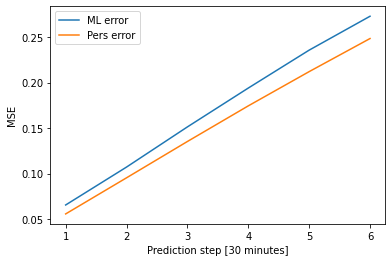

In [114]:
plt.plot(np.arange(1,future_target+1,1), err_ml)
plt.plot(np.arange(1,future_target+1,1), err_pers)
plt.xlabel('Prediction step [30 minutes]')
plt.ylabel('MSE')
plt.legend(['ML error','Pers error'])

In [110]:
nr_classes = 8

precision_pers = np.zeros((nr_classes,future_target))
recall_pers = np.zeros((nr_classes,future_target))
f1_pers = np.zeros((nr_classes,future_target))
balanced_acc_pers = np.zeros(future_target)

precision_ml = np.zeros((nr_classes,future_target))
recall_ml = np.zeros((nr_classes,future_target))
f1_ml = np.zeros((nr_classes,future_target))
balanced_acc_ml = np.zeros(future_target)

for i in range(future_target):
  precision_pers[:,i] = precision_score(y_obs_test[:,i,0], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  precision_ml[:,i] = precision_score(y_obs_test[:,i,0], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)

  recall_pers[:,i] = recall_score(y_obs_test[:,i,0], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  recall_ml[:,i] = recall_score(y_obs_test[:,i,0], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)

  f1_pers[:,i] = f1_score(y_obs_test[:,i,0], y_pers[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  f1_ml[:,i] = f1_score(y_obs_test[:,i,0], y_ml[:,i], 
                                        labels=[0,1,2,3,4,5,6,7], average=None)
  
  balanced_acc_pers[i] = accuracy_score(y_obs_test[:,i,0], y_pers[:,i])
  balanced_acc_ml[i] = accuracy_score(y_obs_test[:,i,0], y_ml[:,i])

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [111]:
def categorical_skill_scores(y_true, y_pred, labels=[0,1,2,3,4,5,6,7]):

  # Compute the confusion matrix
  C = confusion_matrix(y_true, y_pred, labels=labels)
  C = C.transpose()
  nr_fcst = np.sum(C, axis=1)
  nr_obs = np.sum(C, axis=0)
  N = np.sum(nr_obs)

  # Heidke skill score
  HSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_fcst*nr_obs))

  # Peirce skill score
  PSS = (1/N*np.trace(C)-1/N**2*np.sum(nr_fcst*nr_obs))/(1-1/N**2*np.sum(nr_obs**2))

  return HSS, PSS

In [112]:
np.set_printoptions(precision=2)
for i in range(future_target):
  HSS, PSS = categorical_skill_scores(y_obs_test[:,i,0],y_ml[:,i])
  print('Prediction step {}:'.format(i+1))
  print('F1-score ML: {}'.format(f1_ml[:,i]))
  print('F1-score PE: {}'.format(f1_pers[:,i]))
  print('Accuracy ML: {}'.format(np.round(100*balanced_acc_ml[i])/100.0))
  print('Accuracy PE: {}'.format(np.round(100*balanced_acc_pers[i])/100.0))
  print('Heidke skill score ML: {}\nPeirce skill score ML: {}'.format(HSS, PSS))
  HSS, PSS = categorical_skill_scores(y_obs_test[:,i,0],y_pers[:,i])
  print('Heidke skill score PE: {}\nPeirce skill score PE: {}\n'.format(HSS, PSS))

Prediction step 1:
F1-score ML: [0.05 0.72 0.56 0.   0.71 0.81 0.81 0.99]
F1-score PE: [0.7  0.78 0.64 0.39 0.71 0.81 0.81 0.99]
Accuracy ML: 0.95
Accuracy PE: 0.96
Heidke skill score ML: 0.8329733487089366
Peirce skill score ML: 0.8317149899803461
Heidke skill score PE: 0.8415749832449588
Peirce skill score PE: 0.8414831107926611

Prediction step 2:
F1-score ML: [0.09 0.64 0.49 0.   0.6  0.72 0.73 0.99]
F1-score PE: [0.59 0.67 0.52 0.3  0.6  0.72 0.73 0.99]
Accuracy ML: 0.94
Accuracy PE: 0.94
Heidke skill score ML: 0.7748235964346623
Peirce skill score ML: 0.7681911662148954
Heidke skill score PE: 0.7810499328297409
Peirce skill score PE: 0.780964667732602

Prediction step 3:
F1-score ML: [0.09 0.59 0.44 0.   0.55 0.67 0.65 0.98]
F1-score PE: [0.46 0.58 0.43 0.25 0.55 0.66 0.67 0.98]
Accuracy ML: 0.93
Accuracy PE: 0.93
Heidke skill score ML: 0.7253056494873075
Peirce skill score ML: 0.7102341937529089
Heidke skill score PE: 0.7325183255843586
Peirce skill score PE: 0.7324383585508032


In [113]:
for i in range(future_target):
  print('Classification summary ML model at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_obs_test[:,i,0], y_ml[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_obs_test[:,i,0], y_ml[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('\n-----------------------------------------------------------')
  print('-----------------------------------------------------------\n')
  print('Classification summary Persistence at forecast hour {}:\n'.format(i+1))
  print(classification_report(y_obs_test[:,i,0], y_pers[:,i], labels=[0,1,2,3,4,5,6,7]))
  print('Confusion matrix:\n')
  print(confusion_matrix(y_obs_test[:,i,0], y_pers[:,i], labels=[0,1,2,3,4,5,6,7]))  
  print('\n')

Classification summary ML model at forecast hour 1:

              precision    recall  f1-score   support

           0       0.33      0.03      0.05        37
           1       0.61      0.87      0.72       215
           2       0.52      0.61      0.56       268
           3       0.00      0.00      0.00       163
           4       0.67      0.75      0.71       466
           5       0.81      0.81      0.81      1098
           6       0.81      0.81      0.81      1726
           7       0.99      0.99      0.99     22275

    accuracy                           0.95     26248
   macro avg       0.59      0.61      0.58     26248
weighted avg       0.95      0.95      0.95     26248

Confusion matrix:

[[    1    35     0     0     1     0     0     0]
 [    2   188    22     0     1     0     2     0]
 [    0    69   163     0    30     6     0     0]
 [    0     9    86     0    64     4     0     0]
 [    0     5    39     0   350    66     5     1]
 [    0     2     1   

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


[[   26    10     0     0     1     0     0     0]
 [   11   168    32     1     1     0     2     0]
 [    0    36   171    44    11     6     0     0]
 [    0     0    53    63    42     5     0     0]
 [    0     1    11    50   332    67     3     2]
 [    0     0     1     5    73   887   126     6]
 [    0     0     0     0     4   127  1396   199]
 [    0     0     0     0     2     6   198 22069]]


Classification summary ML model at forecast hour 2:

              precision    recall  f1-score   support

           0       0.29      0.05      0.09        37
           1       0.56      0.75      0.64       215
           2       0.44      0.55      0.49       268
           3       0.00      0.00      0.00       163
           4       0.58      0.62      0.60       466
           5       0.72      0.73      0.72      1098
           6       0.74      0.71      0.73      1726
           7       0.99      0.99      0.99     22275

    accuracy                           0.94     